![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

Invasive species are non-native organisms, such as plants, animals, fungi, and even microorganisms, that spread in a new environment. They can damage ecosystems by disrupting their functions and affect economies by impacting people’s activities. It is therefore important to investigate invasive species, including their numbers, distribution, and impacts.

ÜBERGANG

1. When did invasive species introductions peak, and was there a period of rapid increase?
- The number of invasive species is increasing rapidly, with the rate of increase becoming more pronounced from the 2000s onwards.
- The introduction of invasive species reached its highest level between 2010 and 2019.


2. Which region and countries are the most affected by invasive species?
- Africa is the region most affected by invasive species.
- The five countries most affected by invasive species are Spain, Kenya, Brazil, the United States, and Indonesia.


3. Which invasive species has the greater impact?
- Species from the kingdom Plantae have the greatest impact on the environment.
- Species from the kingdom Animalia have the greatest impact on human activities.
- Across all countries, the three animal taxa with the greatest impact on the environment and human activities are Formicidae, Muridae, and Salmonidae.
- Across all countries, the three plant taxa with the greatest impact on the environment and human activities are Solanaceae, Araceae, and Fabaceae.
- The ten species with the greatest impact on the environment are Sirex noctilio, Xanthogaleruca luteola, Ceratopteris thalictroides, Halotydeus destructor, Sminthurus viridis, Brevicoryne brassicae, Lipaphis erysimi, Myzus persicae, Aphis craccivora, and Bombus terrestris.
- The ten species with the greatest impact on human activities are Gambusia affinis, Apiosoma piscicola, Schyzocotyle acheilognathi, Lernaea cyprinacea, Ichthyophthirius multifiliis, Chilodonella piscicola, Chilodonella hexasticha, Argulus japonicus, Cyprinus carpio, and Coptodon rendalli.


---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

The data used in this anlysis comes from the Global Impacts Dataset of Invasive Alien Species (GIDIAS), which has first been published on the 21. of Mai 2025 by Springer Natur and authored by S. Bacher et al.  (https://doi.org/10.6084/m9.figshare.27908838).
The data was downloaded on the 25th of September 2026.

Each row represents one record of a species being invasive in a particular location and region. The location can be a country, a list of countries, or part of a country, such as an island. Each record also includes information about the impact the species has in that location. A species can appear several times in the dataset because it can have impacts of different magnitudes in different locations or regions.

The dataset was split into three tables:
- **Impact**: The impact table contains each recorded impact, represented by the primary key `unique_id`. Each species can appear in several rows because it can have impacts in different locations and with different magnitudes. The species are identified by the foreign key `species_id`, while the location is identified by the foreign key `location_id`.

- **Species**: The species table contains information about each species, such as its name, genus, phylum, and kingdom. Each species is represented only once and is uniquely identified by `species_id`, which is the primary key.

- **Location**: The location table contains information about the locations where invasive species have an impact. The `location_id`, which is the primary key, uniquely identifies each location based on its different location parameters, such as country and region.

![Invasive Species ERD](../images/ERD_invasiv_species_1.png)

---
## 3. Analysis

One section per question: the query, the result, and a sentence saying what it means. Five queries minimum across the notebook, and the aggregation belongs in SQL rather than in pandas afterwards. Keep the queries in `sql/queries.sql` — this notebook runs them.

In [2]:
import sqlite3
import pandas as pd

# point this at wherever you saved the database
DB_PATH = "../project_inv_sp.db"

con = sqlite3.connect(DB_PATH)
print("Connection open")

Connection open


In [3]:
cursor = con.cursor()

In [54]:
with open("../sql/queries.sql", "r") as file:
    queries = file.read().split("--QUERY")

### 3.1 When did invasive species introductions peak, and was there a period of rapid increase?

In [55]:
query = queries[1]
q1h1 = pd.read_sql(query, con)
q1h1

,year,species recorded
0,1600,1
1,1800,1
2,1863,8
3,1868,1
4,1882,1
...,...,...
100,2017,314
101,2018,308
102,2019,438
103,2020,241


In [40]:
query = queries[2]
q1h2 = pd.read_sql(query, con)
q1h2

,decade,species recorded
0,2010,1940


### 3.2 Which region and countries are the most affected by invasive species?

In [41]:
query = queries[3]
q2h1 = pd.read_sql(query, con)
q2h1

,region,species recorded
0,Europe_and_Central_Asia,1675
1,Americas,1335
2,Asia-Pacific,1066
3,Africa,342
4,Antarctica,3


In [43]:
query = queries[4]
q2h2_1 = pd.read_sql(query, con)
q2h2_1

,country,species recorded
0,USA,761
1,Japan,324
2,Ecuador,275
3,South Africa,190
4,Spain,185
...,...,...
406,Antigua and Barbuda,1
407,Antarctica,1
408,American Samoa,1
409,Albania; France; Austria; United Kingdom; Swit...,1


In [45]:
query = queries[5]
q2h2_2 = pd.read_sql(query, con)
q2h2_2

,country,species recorded
0,USA,786
1,Japan,324
2,Ecuador,285
3,Spain,210
4,South Africa,194


### 3.3 Which invasive species has the greater impact?

In [103]:
query = queries[6]
q3h1 = pd.read_sql(query, con)
q3h1

,kingdom,magnitude 3,magnitude 2,magnitude 1,magnitude 0
0,Animalia,171,390,525,221
1,Plantae,51,425,451,210
2,Fungi,5,19,8,7
3,Chromista,2,13,9,3
4,Viruses,1,3,5,0
5,Protozoa,1,2,2,0
6,Bacteria,0,2,1,0


In [47]:
query = queries[7]
q3h2 = pd.read_sql(query, con)
q3h2

,kingdom,magnitude 3,magnitude 2,magnitude 1,magnitude 0,positive impact
0,Animalia,19,108,224,66,1
1,Plantae,18,33,81,17,2
2,Viruses,2,2,3,0,0
3,Fungi,1,6,5,0,0
4,Bacteria,1,1,0,0,0
5,Chromista,0,1,2,1,0
6,incertae sedis,0,1,0,0,0


In [48]:
query = queries[8]
q3h3_1 = pd.read_sql(query, con)
q3h3_1

,country,family,magnitude 3
0,Ecuador,Formicidae,8
1,Ecuador,Muridae,2
2,Ecuador,Bovidae,2
3,Ecuador,Suidae,1
4,Ecuador,Muscidae,1
...,...,...,...
59,USA,Buprestidae,1
60,USA,Bopyridae,1
61,USA,Batillariidae,1
62,USA,Anatidae,1


In [49]:
query = queries[9]
q3h3_2 = pd.read_sql(query, con)
q3h3_2

,country,family,magnitude 3
0,South Africa,Corvidae,1
1,USA,Formicidae,1
2,USA,Buprestidae,1


In [50]:
query = queries[10]
q3h4_1 = pd.read_sql(query, con)
q3h4_1

,country,family,magnitude 3
0,Ecuador,Solanaceae,1
1,Ecuador,Meliaceae,1
2,Japan,Pontederiaceae,1
3,Japan,Moraceae,1
4,Japan,Hydrocharitaceae,1
5,South Africa,Salviniaceae,2
6,South Africa,Pontederiaceae,1
7,South Africa,Pinaceae,1
8,South Africa,Myrtaceae,1
9,South Africa,Fabaceae,1


In [51]:
query = queries[11]
q3h4_2 = pd.read_sql(query, con)
q3h4_2

,country,family,magnitude 3
0,South Africa,Salviniaceae,1


In [52]:
query = queries[12]
q3h5_1 = pd.read_sql(query, con)
q3h5_1

,species,magnitude 3,magnitude 2,magnitude 1
0,Felis catus,108,34,13
1,Rattus rattus,74,35,51
2,Vulpes vulpes,69,17,3
3,Linepithema humile,50,26,43
4,Rattus exulans,41,28,13
5,Pterois volitans,39,69,15
6,Anoplolepis gracilipes,29,21,45
7,Solenopsis invicta,28,62,76
8,Capra hircus,27,32,15
9,Caulerpa taxifolia,21,29,8


In [56]:
query = queries[13]
q3h5_2 = pd.read_sql(query, con)
q3h5_2

,species,magnitude 3,magnitude 2,magnitude 1
0,Eichhornia crassipes,21,14,19
1,Corvus splendens,6,3,5
2,Agrilus planipennis,3,14,12
3,Rhinella marina,3,6,15
4,Dengue virus,3,0,25
5,Wasmannia auropunctata,2,7,15
6,Salvinia molesta,2,2,10
7,Mikania micrantha,2,1,1
8,Solenopsis invicta,1,8,60
9,Vespa velutina nigrithorax,1,3,1


---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

#### Question 1

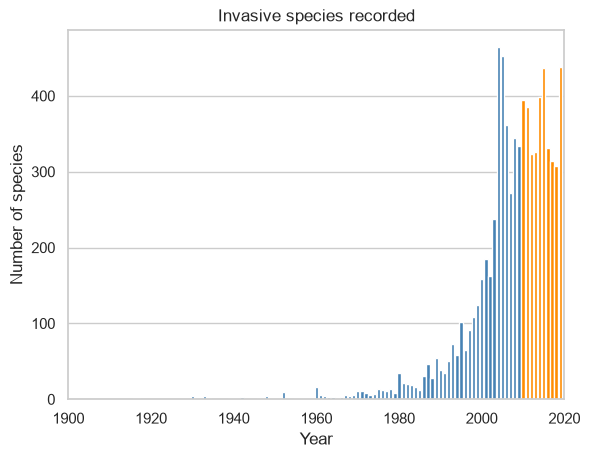

In [73]:
colors = ["darkorange" if 2010 <= year <= 2019 else "steelblue"
    for year in q1h1["year"]]

plt.bar(q1h1["year"], q1h1["species recorded"], 
    color=colors,
    alpha=1)
plt.xlabel("Year")
plt.ylabel("Number of species")
plt.title("Invasive species recorded")
plt.grid(axis="x")
plt.xlim(1900, 2020)
plt.gca().set_axisbelow(True)
plt.show()

#### Question 2

C:\Users\zoed\AppData\Local\Temp\ipykernel_16452\2692047460.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plt_q2h1.set_xticklabels(labels)


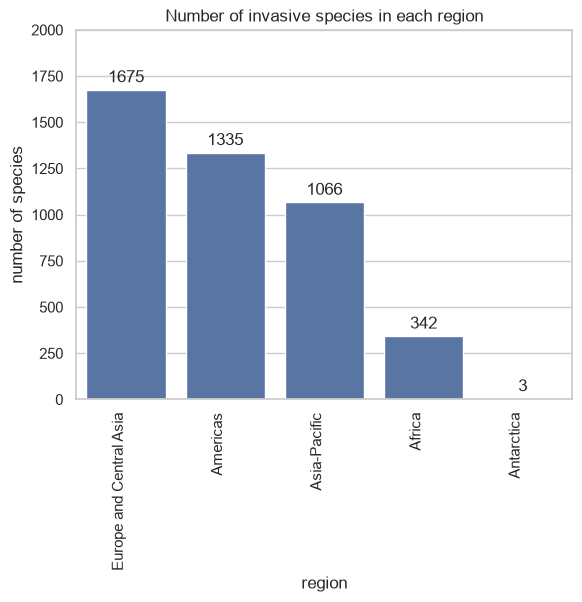

In [ ]:

plt_q2h1 = sns.barplot(q2h1, x="region", y="species recorded")
plt_q2h1.set_ylim(0, 2000)
plt_q2h1.set_title("Number of invasive species in each region")
plt_q2h1.set_ylabel("number of species")
labels = [label.get_text().replace("_", " ") for label in plt_q2h1.get_xticklabels()]
plt_q2h1.set_xticklabels(labels)
plt.xticks(rotation=90, ha="right")

for container in plt_q2h1.containers:
    plt_q2h1.bar_label(container, fmt="%.0f", padding=3)

plt.show()


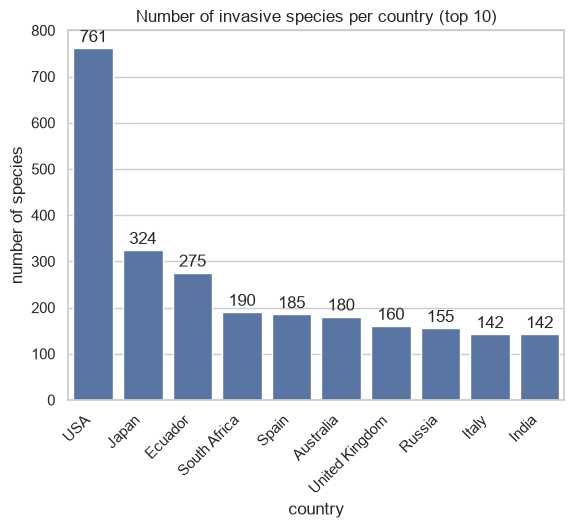

In [96]:
top_10 = q2h2_1.head(10)
plt_q2h2 = sns.barplot(top_10, x="country", y="species recorded")
plt_q2h2.set_ylim(0,  800)
plt_q2h2.set_title("Number of invasive species per country (top 10)")
plt_q2h2.set_ylabel("number of species")
plt.xticks(rotation=45, ha="right")

for container in plt_q2h2.containers:
    plt_q2h2.bar_label(container, fmt="%.0f", padding=2)

plt.show()


### Question 3

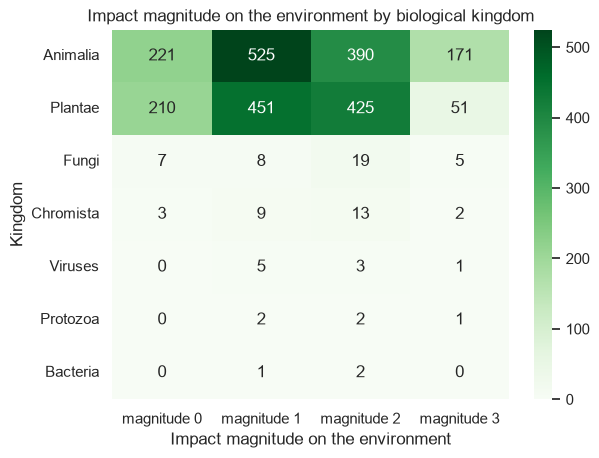

In [ ]:
index_q3h1 = q3h1.set_index("kingdom")[["magnitude 0", "magnitude 1", "magnitude 2", "magnitude 3"]]
sns.heatmap(
    index_q3h1,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Impact magnitude on the environment")
plt.ylabel("Kingdom")
plt.title("Impact magnitude on the environment by biological kingdom")
plt.show()

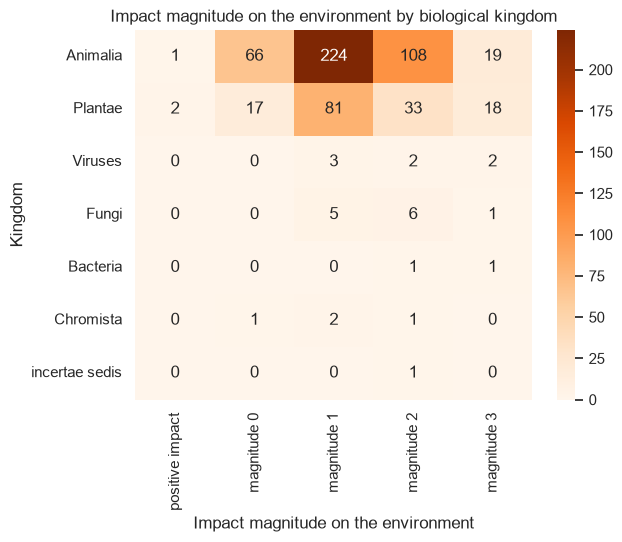

In [112]:
index_q3h2 = q3h2.set_index("kingdom")[["positive impact","magnitude 0", "magnitude 1", "magnitude 2", "magnitude 3"]]
sns.heatmap(
    index_q3h2,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Impact magnitude on the environment")
plt.ylabel("Kingdom")
plt.title("Impact magnitude on the environment by biological kingdom")
plt.show()

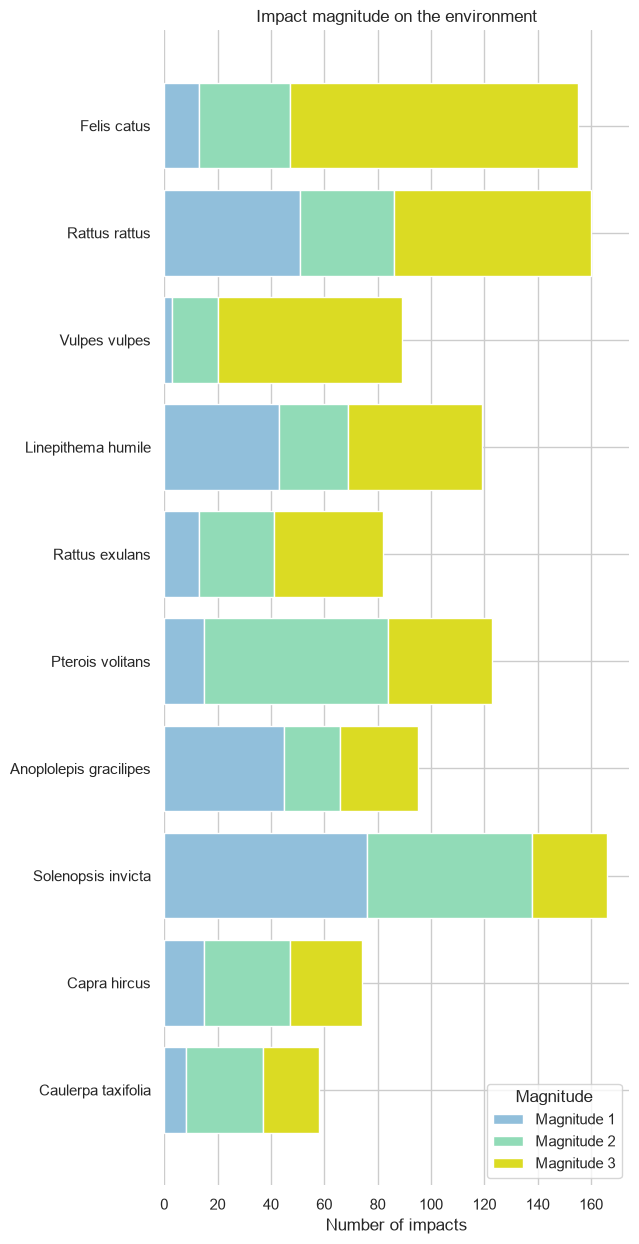

In [117]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))

ax.barh(
    q3h5_1["species"],
    q3h5_1["magnitude 1"],
    label = "Magnitude 1",
    color = "#91bfdb")
ax.barh(
    q3h5_1["species"],
    q3h5_1["magnitude 2"],
    left=q3h5_1["magnitude 1"],
    label = "Magnitude 2",
    color = "#91dbb7")
ax.barh(
    q3h5_1["species"],
    q3h5_1["magnitude 3"],
    left=q3h5_1["magnitude 1"] + q3h5_1["magnitude 2"],
    label = "Magnitude 3",
    color = "#dbdb23")

ax.set_xlabel("Number of impacts")
ax.set_ylabel("")
ax.set_title("Impact magnitude on the environment")

ax.legend(title="Magnitude")
ax.invert_yaxis()

sns.despine(left=True, bottom=True)

plt.show()


---
## 5. Conclusions

Answer each question. Say whether your hypothesis held. Being wrong is a fine result, as long as you say so and show the evidence.

---
## 6. Limitations and next steps

What this data cannot tell you, and what you would do with another week. Knowing the limits of your own analysis is part of the grade.